In [8]:
from langgraph.graph import StateGraph, START, MessagesState, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [4]:
def chat_node(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [6]:
graph = StateGraph(MessagesState)
graph.add_node('chat', chat_node)
graph.add_edge(START, 'chat')
graph.add_edge('chat', END)

## Normal Implementation -> Without MemorySaver

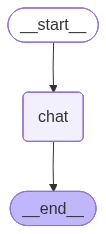

In [7]:
workflow = graph.compile()
workflow

## Memory Implemented 

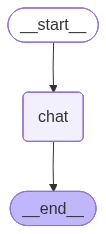

In [9]:
checkpointer = InMemorySaver()
workflow2 = graph.compile(checkpointer=checkpointer)
workflow2 

## Testing Pipeline

In [10]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
workflow.invoke({"messages": [{"role": "user", "content": "Hi! My name is Harsh."}]})

{'messages': [HumanMessage(content='Hi! My name is Harsh.', additional_kwargs={}, response_metadata={}, id='b8b97303-218f-4cf4-ac62-f087120df906'),
  AIMessage(content="Hello, Harsh! 👋 I'm ChatGPT. How can I assist you today?", additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Harsh." Likely a greeting. We should respond politely, introduce ourselves, ask how can we help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 79, 'total_tokens': 142, 'completion_time': 0.130801351, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.013806624, 'prompt_tokens_details': None, 'queue_time': 0.307756258, 'total_time': 0.144607975}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4140daa9c2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecbda-d0e1-7ec3-88d2-23aab4ba2d2d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata

In [14]:
workflow.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='7f47dd97-bef0-4e06-a579-372f72f8352b'),
  AIMessage(content='I don’t have any information about your name. If you’d like to share it, feel free to let me know!', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" There\'s no prior context. According to policy, we must not guess personal info. We should respond that we don\'t know the name. Ask politely if they\'d like to tell.'}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 76, 'total_tokens': 154, 'completion_time': 0.166028138, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.003594932, 'prompt_tokens_details': None, 'queue_time': 0.043557837, 'total_time': 0.16962307}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01

In [17]:
workflow2.invoke({"messages": [{"role": "user", "content": "Hi! My name is Harsh."}]},config=config)

{'messages': [HumanMessage(content='Hi! My name is Harsh.', additional_kwargs={}, response_metadata={}, id='460b0f6f-0951-4996-9ce6-6a98cf1b6a73'),
  AIMessage(content='Hello, Harsh! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi! My name is Harsh." Probably greet back, ask how can help. Should follow policy: friendly.'}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 79, 'total_tokens': 138, 'completion_time': 0.124607884, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.003593156, 'prompt_tokens_details': None, 'queue_time': 0.276502218, 'total_time': 0.12820104}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_87b3c396db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecbdb-f20c-7901-8d4f-982cf9a2371e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [18]:
workflow2.invoke({"messages": [{"role": "user", "content": "What is my name?"}]},config=config)

{'messages': [HumanMessage(content='Hi! My name is Harsh.', additional_kwargs={}, response_metadata={}, id='460b0f6f-0951-4996-9ce6-6a98cf1b6a73'),
  AIMessage(content='Hello, Harsh! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi! My name is Harsh." Probably greet back, ask how can help. Should follow policy: friendly.'}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 79, 'total_tokens': 138, 'completion_time': 0.124607884, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.003593156, 'prompt_tokens_details': None, 'queue_time': 0.276502218, 'total_time': 0.12820104}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_87b3c396db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecbdb-f20c-7901-8d4f-982cf9a2371e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [19]:
workflow2.invoke({"messages": [{"role": "user", "content": "What is my name?"}]},config=config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='75ff75d2-91e6-4204-8362-166217ef5ad2'),
  AIMessage(content='I’m sorry, but I don’t have that information. Could you remind me what you’d like to be called?', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" There\'s no prior context. According to policy, we must not guess personal info. We should respond that we don\'t know and ask politely.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 76, 'total_tokens': 146, 'completion_time': 0.147169621, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.003004772, 'prompt_tokens_details': None, 'queue_time': 0.287711748, 'total_time': 0.150174393}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecbdc-7570-7772-9eb9-ade77e1656